Exploring kNN on NABs for benchmarking

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import io

In [5]:
art_daily = pd.read_csv('C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/NAB-master/data/artificialNoAnomaly/art_daily_no_noise.csv', index_col=0, parse_dates=True)

art_daily.head(100)

,value
timestamp,
2014-04-01 00:00:00,20.0
2014-04-01 00:05:00,20.0
2014-04-01 00:10:00,20.0
2014-04-01 00:15:00,20.0
2014-04-01 00:20:00,20.0
...,...
2014-04-01 07:55:00,20.0
2014-04-01 08:00:00,20.0
2014-04-01 08:05:00,20.0


In [ ]:
# Plot art_daily_no_noise against time
plt.figure(figsize=(12, 4))
plt.plot(art_daily.index, art_daily['value'])
plt.xlabel('time')
plt.ylabel('value')
plt.title('art_daily_no_noise')
plt.tight_layout()
plt.show()

AWS CloudWatch data (realAWSCloudwatch)

In [4]:
# Load every AWS CloudWatch stream in the realAWSCloudwatch folder, each into its own DataFrame
aws_dir = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/NAB-master/data/realAWSCloudwatch'

aws_files = sorted(f for f in os.listdir(aws_dir) if f.endswith('.csv'))

aws_data = {
    os.path.splitext(f)[0]: pd.read_csv(os.path.join(aws_dir, f), index_col=0, parse_dates=True)
    for f in aws_files
}

print(len(aws_data), 'AWS CloudWatch streams loaded')
for name, stream_df in aws_data.items():
    print(name, stream_df.shape)

17 AWS CloudWatch streams loaded
ec2_cpu_utilization_24ae8d (4032, 1)
ec2_cpu_utilization_53ea38 (4032, 1)
ec2_cpu_utilization_5f5533 (4032, 1)
ec2_cpu_utilization_77c1ca (4032, 1)
ec2_cpu_utilization_825cc2 (4032, 1)
ec2_cpu_utilization_ac20cd (4032, 1)
ec2_cpu_utilization_c6585a (4032, 1)
ec2_cpu_utilization_fe7f93 (4032, 1)
ec2_disk_write_bytes_1ef3de (4730, 1)
ec2_disk_write_bytes_c0d644 (4032, 1)
ec2_network_in_257a54 (4032, 1)
ec2_network_in_5abac7 (4730, 1)
elb_request_count_8c0756 (4032, 1)
grok_asg_anomaly (4621, 1)
iio_us-east-1_i-a2eb1cd9_NetworkIn (1243, 1)
rds_cpu_utilization_cc0c53 (4032, 1)
rds_cpu_utilization_e47b3b (4032, 1)


In [ ]:
# Plot each AWS CloudWatch stream separately, against time
for name, stream_df in aws_data.items():
    plt.figure(figsize=(12, 4))
    plt.plot(stream_df.index, stream_df['value'])
    plt.xlabel('time')
    plt.ylabel('value')
    plt.title(name)
    plt.tight_layout()
    plt.show()

Base normal corpus: day-long windows sampled from `ec2_cpu_utilization_ac20cd`

One day-long (24h, 5-minute resolution -> 288 points) window per valid start position between 2014-04-05 and 2014-04-15 - no oversampling, so no duplicate windows (unlike sampling 10,000 windows with replacement from the much smaller pool of possible starts). Built in the long-format layout `signature_computer.split_streams`/`vectorize` expect: a `time` column that counts up within a window and resets at the start of the next one, plus the feature column(s) - here just `value`.

In [ ]:
target = aws_data['ec2_cpu_utilization_ac20cd']

# infer the data's sampling resolution, and how many points make up a 24h window
resolution = target.index.to_series().diff().median()
samples_per_day = int(pd.Timedelta(days=1) / resolution)
print('resolution:', resolution, '-> samples per day:', samples_per_day)

window_start_lo = pd.Timestamp('2014-04-05')
window_start_hi = pd.Timestamp('2014-04-15')

valid_start_positions = np.where((target.index >= window_start_lo) & (target.index < window_start_hi))[0]
assert valid_start_positions[-1] + samples_per_day < len(target), \
    'not enough data after the last valid start for a full day-long window'

rng = np.random.default_rng(42)

# one window per valid start position - no oversampling/replacement, so no duplicate windows
start_positions = valid_start_positions
n_windows = len(start_positions)

# vectorised window extraction: one row of positions per window, gathered in a single index
window_positions = start_positions[:, None] + np.arange(samples_per_day)[None, :]
values = target['value'].to_numpy()[window_positions]

elapsed_minutes = np.arange(samples_per_day) * (resolution / pd.Timedelta(minutes=1))

base_corpus = pd.DataFrame({
    'time': np.tile(elapsed_minutes, n_windows),
    'value': values.reshape(-1),
})

print(base_corpus.shape, '- expected', (n_windows * samples_per_day, 2))
base_corpus.head()

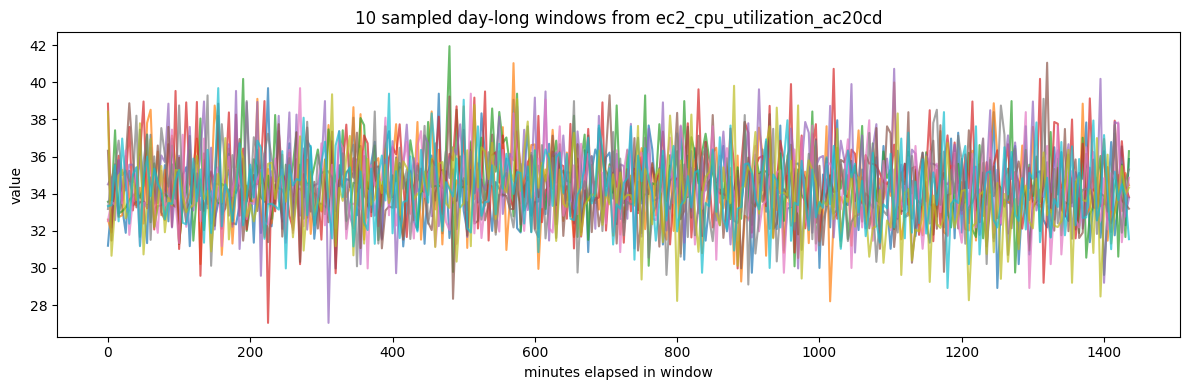

In [6]:
# Sanity check: overlay a handful of the sampled windows
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.plot(elapsed_minutes, values[i], alpha=0.7)
plt.xlabel('minutes elapsed in window')
plt.ylabel('value')
plt.title('10 sampled day-long windows from ec2_cpu_utilization_ac20cd')
plt.tight_layout()
plt.show()

Test set: 50 anomalous + 50 normal windows

Anomalous windows are sampled from outside the base corpus's date range (2014-04-05 to 2014-04-15) - i.e. from the start/end of the series the base corpus never drew from. Normal windows are sampled again from inside that same range. `test_corpus` holds the streams in the `signature_computer` layout; `test_labels` carries the 'anomalous'/'normal' ground truth and start time for each window, one row per stream in the same order.

In [ ]:
# All positions where a full day-long window fits, split into "inside" (base corpus's date
# range) and "outside" (everywhere else in the series) pools
all_start_positions = np.arange(len(target) - samples_per_day + 1)
in_range_mask = (target.index[all_start_positions] >= window_start_lo) & (target.index[all_start_positions] < window_start_hi)
outside_start_positions = all_start_positions[~in_range_mask]

n_anomalous = 50
n_normal = 50
assert len(outside_start_positions) >= n_anomalous, 'not enough out-of-range windows available'

anomalous_starts = rng.choice(outside_start_positions, size=n_anomalous, replace=False)
normal_starts = rng.choice(valid_start_positions, size=n_normal, replace=False)

def extract_windows(start_positions):
    window_positions = start_positions[:, None] + np.arange(samples_per_day)[None, :]
    return target['value'].to_numpy()[window_positions]

anomalous_values = extract_windows(anomalous_starts)
normal_values = extract_windows(normal_starts)
test_values = np.concatenate([anomalous_values, normal_values], axis=0)

test_corpus = pd.DataFrame({
    'time': np.tile(elapsed_minutes, n_anomalous + n_normal),
    'value': test_values.reshape(-1),
})

test_labels = pd.DataFrame({
    'window_id': np.arange(n_anomalous + n_normal),
    'label': ['anomalous'] * n_anomalous + ['normal'] * n_normal,
    'window_start': target.index[np.concatenate([anomalous_starts, normal_starts])],
})

print(test_corpus.shape, '- expected', ((n_anomalous + n_normal) * samples_per_day, 2))
print(test_labels['label'].value_counts())
test_labels.head()

True NAB ground-truth labels, for comparison

`label` above is a heuristic proxy (out-of-range date = "anomalous"), not NAB's actual annotations. `label_nab_true` labels the same `test_labels` windows using the real labelled anomaly timestamps from `labels/combined_labels.json`: a window is 'anomalous' if it contains at least one of the stream's ground-truth anomaly timestamps. It's added alongside `label` rather than replacing it - `ec2_cpu_utilization_ac20cd` only has one true labelled anomaly in the whole series, so `label_nab_true`'s positive class is tiny and not a drop-in replacement for the balanced heuristic used by the precision/recall analysis below.

In [ ]:
import sys

scripts_dir = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/scripts'
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)

from nab_labels import load_anomaly_timestamps, label_windows

labels_path = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/NAB-master/labels/combined_labels.json'
stream_relative_path = 'realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv'

anomaly_timestamps = load_anomaly_timestamps(labels_path, stream_relative_path)
window_length = pd.Timedelta(minutes=elapsed_minutes[-1])  # start to each window's last point

test_labels['label_nab_true'] = label_windows(test_labels['window_start'], window_length, anomaly_timestamps)

print('ground-truth anomaly timestamps in this stream:', list(anomaly_timestamps))
print(test_labels['label_nab_true'].value_counts())
test_labels[test_labels['label_nab_true'] == 'anomalous']

In [ ]:
# Sanity check: anomalous vs normal test windows
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for values_i in anomalous_values:
    axes[0].plot(elapsed_minutes, values_i, alpha=0.6)
axes[0].set_title('anomalous (out-of-range) windows')
axes[0].set_xlabel('minutes elapsed in window')
axes[0].set_ylabel('value')

for values_i in normal_values:
    axes[1].plot(elapsed_minutes, values_i, alpha=0.6)
axes[1].set_title('normal (in-range) windows')
axes[1].set_xlabel('minutes elapsed in window')

plt.tight_layout()
plt.show()

Anomaly detection: Mahalanobis-whitened FAISS kNN scoring

Uses `base_corpus` as the training corpus and `test_corpus` (the merged in-range/out-of-range windows) as the streams to score, via `signature_computer.py` (which now also holds `build_covariance_matrix`/`transform_signatures`) and `score_streams.py`: compute signatures, whiten them with the training corpus's covariance so L2 nearest-neighbour distance is equivalent to Mahalanobis distance in the original signature space, then score with FAISS (`use_faiss=True`).

In [ ]:
import sys

scripts_dir = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/scripts'
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)

from signature_computer import vectorize, convert_np, transform_signatures
from score_streams import faiss_kNN, score_streams, Calibration, Thresholding

In [ ]:
# Compute signatures for the training corpus and the streams to be tested. vectorize() now
# also returns the Mahalanobis covariance matrix fit on the corpus's own raw signatures.
TRUNC = 4

train_sig, train_covariance = vectorize(base_corpus, trunc=TRUNC, show_progress=True)
test_sig, _ = vectorize(test_corpus, trunc=TRUNC, show_progress=True)

print('train_sig', train_sig.shape, '- test_sig', test_sig.shape, '- train_covariance', train_covariance.shape)

In [ ]:
# Whiten the signatures using the training corpus's own covariance (now returned directly by
# vectorize), so L2 nearest-neighbour search is equivalent to Mahalanobis distance in the
# original signature space
L_inv = train_covariance

train_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(train_sig), L_inv))})
test_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(test_sig), L_inv))})

In [ ]:
# Score every test stream against the training corpus using FAISS, and save the distances
K = 6

distances, indices = faiss_kNN(train_whitened, test_whitened, k=K)
scores, scores_max, scores_min = score_streams(train_whitened, test_whitened, k=K, use_faiss=True)

results = test_labels.copy()
for i in range(K):
    results['dist_{0}'.format(i + 1)] = distances[:, i]
results['score_mean'] = scores
results['score_max'] = scores_max
results['score_min'] = scores_min

output_path = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/data/nab_ec2_cpu_utilization_ac20cd_distances.csv'
results.to_csv(output_path, index=False)
print('saved to', output_path)

print(results.groupby('label')['score_mean'].describe())
results.sort_values('score_mean', ascending=False).head(10)

Calibrating a threshold and scoring classification metrics

`Calibration`/`Thresholding` need a threshold set from data known to be normal, not from `test_corpus` itself (that's a 50/50 mix, so its own 95th percentile would badly under-flag anomalies). So a separate 200-window normal-only calibration set is sampled from the same in-range pool, held out from the 50 windows already used as `test_corpus`'s normal half. `Calibration` scores it against the training corpus and takes the 95th percentile as the threshold; `Thresholding` then flags any `test_corpus` window whose score exceeds it.

In [ ]:
# Normal-only calibration set, held out from the normal windows already used in test_corpus
n_calibration = 200
calibration_pool = np.setdiff1d(valid_start_positions, normal_starts)
calibration_starts = rng.choice(calibration_pool, size=n_calibration, replace=False)
calibration_values = extract_windows(calibration_starts)

calibration_corpus = pd.DataFrame({
    'time': np.tile(elapsed_minutes, n_calibration),
    'value': calibration_values.reshape(-1),
})

calibration_sig, _ = vectorize(calibration_corpus, trunc=TRUNC, show_progress=False)
calibration_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(calibration_sig), L_inv))})

Threshold = Calibration(train_whitened, calibration_whitened, k=K, use_faiss=True)
print('calibrated threshold (95th percentile of normal calibration scores):', Threshold)

In [ ]:
# Flag each test window as anomalous/normal using the calibrated threshold, and re-save
anomaly_flags = Thresholding(scores, Threshold)
results['predicted_label'] = np.where(anomaly_flags, 'anomalous', 'normal')

results.to_csv(output_path, index=False)
print('saved to', output_path)

results[['window_id', 'label', 'predicted_label', 'score_mean']]

In [ ]:
# Classification metrics against the ground-truth labels, treating 'anomalous' as positive
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix

y_true = results['label']
y_pred = results['predicted_label']

precision = precision_score(y_true, y_pred, pos_label='anomalous')
recall = recall_score(y_true, y_pred, pos_label='anomalous')
accuracy = accuracy_score(y_true, y_pred)

print('precision: {0:.3f}'.format(precision))
print('recall:    {0:.3f}'.format(recall))
print('accuracy:  {0:.3f}'.format(accuracy))

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=['normal', 'anomalous']).ravel()
pd.DataFrame([[tn, fp], [fn, tp]],
             index=['true normal', 'true anomalous'],
             columns=['predicted normal', 'predicted anomalous'])

Baseline strategy: summary statistics + kNN

Compares the signature-based approach above against a simpler alternative: each window reduced to 5 summary statistics (mean, std, min, max, median) instead of a path signature, z-scored using the training corpus's own mean/std so no single statistic dominates the L2 distance, then scored with the same `score_streams`/`Calibration`/`Thresholding` machinery (FAISS, k=6, 95th-percentile threshold from the same calibration set) for a like-for-like comparison.

In [ ]:
def summary_stats(window_values):
    return np.column_stack([
        window_values.mean(axis=1),
        window_values.std(axis=1),
        window_values.min(axis=1),
        window_values.max(axis=1),
        np.median(window_values, axis=1),
    ])

train_stats = summary_stats(values)
test_stats = summary_stats(test_values)
calibration_stats = summary_stats(calibration_values)

# z-score using the training corpus's own mean/std
stat_mean = train_stats.mean(axis=0)
stat_std = train_stats.std(axis=0)
stat_std[stat_std == 0] = 1.0  # guard against a constant statistic

train_stats_df = pd.DataFrame({'Sig': list((train_stats - stat_mean) / stat_std)})
test_stats_df = pd.DataFrame({'Sig': list((test_stats - stat_mean) / stat_std)})
calibration_stats_df = pd.DataFrame({'Sig': list((calibration_stats - stat_mean) / stat_std)})

stats_scores, _, _ = score_streams(train_stats_df, test_stats_df, k=K, use_faiss=True)
stats_threshold = Calibration(train_stats_df, calibration_stats_df, k=K, use_faiss=True)
results['score_mean_stats'] = stats_scores
results['predicted_label_stats'] = np.where(Thresholding(stats_scores, stats_threshold), 'anomalous', 'normal')

stats_precision = precision_score(results['label'], results['predicted_label_stats'], pos_label='anomalous')
stats_recall = recall_score(results['label'], results['predicted_label_stats'], pos_label='anomalous')
stats_accuracy = accuracy_score(results['label'], results['predicted_label_stats'])

print('summary-statistics + kNN baseline (threshold {0:.3g}):'.format(stats_threshold))
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}'.format(stats_precision, stats_recall, stats_accuracy))
print('\nsignature + Mahalanobis kNN, for comparison:')
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}'.format(precision, recall, accuracy))

results.to_csv(output_path, index=False)
print('\nsaved to', output_path)

Further baselines: Local Outlier Factor and Isolation Forest, on both feature representations

Extends the comparison to two more standard scikit-learn detectors, each run on both feature sets already built above: the whitened signatures (`train_whitened`/`calibration_whitened`/`test_whitened`) and the z-scored summary statistics (`train_stats_df`/`calibration_stats_df`/`test_stats_df`). Both LOF (`novelty=True`) and Isolation Forest are fit on the training corpus only; their `score_samples` (higher = more normal) is negated so higher means more anomalous, matching the convention used everywhere else in this notebook, and the same calibration-set-95th-percentile approach sets the threshold.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

def outlier_scores(estimator, X_train, X_calib, X_test):
    """Fit `estimator` on X_train, calibrate a threshold from the 95th percentile of X_calib's
    outlier scores, and score X_test - all in the "higher = more anomalous" convention used
    by score_streams/Thresholding elsewhere in this notebook."""
    estimator.fit(X_train)
    calib_scores = -estimator.score_samples(X_calib)
    threshold = np.percentile(calib_scores, 95)
    test_scores = -estimator.score_samples(X_test)
    return test_scores, threshold

feature_sets = {
    'signature': (convert_np(train_whitened), convert_np(calibration_whitened), convert_np(test_whitened)),
    'summary_stats': (convert_np(train_stats_df), convert_np(calibration_stats_df), convert_np(test_stats_df)),
}

comparison_rows = [
    {'method': 'kNN (signature)', 'precision': precision, 'recall': recall, 'accuracy': accuracy},
    {'method': 'kNN (summary stats)', 'precision': stats_precision, 'recall': stats_recall, 'accuracy': stats_accuracy},
]

for feature_name, (X_train, X_calib, X_test) in feature_sets.items():
    for model_name, estimator in [
        ('LOF', LocalOutlierFactor(n_neighbors=K, novelty=True)),
        ('IsolationForest', IsolationForest(random_state=42)),
    ]:
        test_scores, threshold = outlier_scores(estimator, X_train, X_calib, X_test)
        predicted = np.where(Thresholding(test_scores, threshold), 'anomalous', 'normal')

        col = '{0}_{1}'.format(model_name.lower(), feature_name)
        results['score_{0}'.format(col)] = test_scores
        results['predicted_label_{0}'.format(col)] = predicted

        comparison_rows.append({
            'method': '{0} ({1})'.format(model_name, feature_name),
            'precision': precision_score(results['label'], predicted, pos_label='anomalous'),
            'recall': recall_score(results['label'], predicted, pos_label='anomalous'),
            'accuracy': accuracy_score(results['label'], predicted),
        })

comparison = pd.DataFrame(comparison_rows).set_index('method')

results.to_csv(output_path, index=False)
print('saved to', output_path)

comparison

k-sensitivity: sweeping k = 1, 5, 10, 20

Re-runs kNN and LOF (both feature sets) at k in {1, 5, 10, 20} - the two methods where k actually means something (Isolation Forest has no k; its result from above is fixed regardless and isn't repeated here). Each k gets its own calibrated threshold from the same calibration set, so this reflects how each method would actually be tuned at that k, not just the raw score ranking.

In [ ]:
k_values = [1, 5, 10, 20]
sweep_rows = []

for k_val in k_values:
    # kNN on both feature sets
    for feature_name, (train_df, calib_df, test_df) in [
        ('signature', (train_whitened, calibration_whitened, test_whitened)),
        ('summary_stats', (train_stats_df, calibration_stats_df, test_stats_df)),
    ]:
        knn_scores, _, _ = score_streams(train_df, test_df, k=k_val, use_faiss=True)
        knn_threshold = Calibration(train_df, calib_df, k=k_val, use_faiss=True)
        knn_predicted = np.where(Thresholding(knn_scores, knn_threshold), 'anomalous', 'normal')
        sweep_rows.append({
            'k': k_val, 'method': 'kNN', 'features': feature_name,
            'precision': precision_score(results['label'], knn_predicted, pos_label='anomalous'),
            'recall': recall_score(results['label'], knn_predicted, pos_label='anomalous'),
            'accuracy': accuracy_score(results['label'], knn_predicted),
        })

    # LOF on both feature sets, n_neighbors = k_val
    for feature_name, (X_train, X_calib, X_test) in feature_sets.items():
        lof_scores, lof_threshold = outlier_scores(
            LocalOutlierFactor(n_neighbors=k_val, novelty=True), X_train, X_calib, X_test)
        lof_predicted = np.where(Thresholding(lof_scores, lof_threshold), 'anomalous', 'normal')
        sweep_rows.append({
            'k': k_val, 'method': 'LOF', 'features': feature_name,
            'precision': precision_score(results['label'], lof_predicted, pos_label='anomalous'),
            'recall': recall_score(results['label'], lof_predicted, pos_label='anomalous'),
            'accuracy': accuracy_score(results['label'], lof_predicted),
        })

sweep = pd.DataFrame(sweep_rows)
sweep

In [ ]:
# Visualise precision/recall/accuracy vs k, one line per method+feature combination
series_colors = {
    ('kNN', 'signature'): '#2a78d6',
    ('kNN', 'summary_stats'): '#eb6834',
    ('LOF', 'signature'): '#1baf7a',
    ('LOF', 'summary_stats'): '#eda100',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)

for metric, ax in zip(['precision', 'recall', 'accuracy'], axes):
    for (method, features), color in series_colors.items():
        subset = sweep[(sweep['method'] == method) & (sweep['features'] == features)].sort_values('k')
        ax.plot(subset['k'], subset[metric], color=color, linewidth=2, marker='o', markersize=6,
                label='{0} ({1})'.format(method, features))
    ax.set_title(metric)
    ax.set_xlabel('k')
    ax.set_xticks(k_values)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, color='#e1e0d9', linewidth=1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#c3c2b7')
    ax.tick_params(colors='#898781')

axes[0].set_ylabel('score')
axes[-1].legend(loc='lower right', frameon=False)
fig.suptitle('Precision / recall / accuracy vs k')
plt.tight_layout()
plt.show()

NYC Taxi data (realKnownCause/nyc_taxi.csv)

Half-hourly NYC taxi ride counts from 2014-07-01 to 2015-01-31, one of NAB's `realKnownCause` streams - each of its anomalies has a known real-world cause (NYC marathon, Thanksgiving, Christmas, New Year's Eve, a snowstorm). Ground-truth timestamps are pulled from `labels/combined_labels.json` via `nab_labels.load_anomaly_timestamps`, the same helper used to label windows earlier in this notebook.

In [ ]:
taxi_path = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/NAB-master/data/realKnownCause/nyc_taxi.csv'
taxi_data = pd.read_csv(taxi_path, index_col=0, parse_dates=True)

print(taxi_data.shape)
taxi_data.head()

In [ ]:
import sys

scripts_dir = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/scripts'
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)

from nab_labels import load_anomaly_timestamps

labels_path = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/NAB-master/labels/combined_labels.json'
taxi_relative_path = 'realKnownCause/nyc_taxi.csv'

taxi_anomaly_timestamps = load_anomaly_timestamps(labels_path, taxi_relative_path)

print('known-cause anomalies in nyc_taxi:')
for ts in taxi_anomaly_timestamps:
    print(' ', ts)

In [ ]:
# Plot the series with the known-cause anomalies overlaid as dashed vertical lines
plt.figure(figsize=(14, 4))
plt.plot(taxi_data.index, taxi_data['value'], linewidth=1)
for ts in taxi_anomaly_timestamps:
    plt.axvline(ts, color='#c0392b', linestyle='--', alpha=0.7)
plt.xlabel('time')
plt.ylabel('value')
plt.title('nyc_taxi - half-hourly ride counts, with known-cause anomalies (dashed)')
plt.tight_layout()
plt.show()

Base corpus for nyc_taxi: day-long windows, 12h stride, July-October 2014

Builds a base/training corpus from `nyc_taxi`, analogous to the `ec2_cpu_utilization_ac20cd` corpus earlier, but windowed explicitly rather than one window per valid start position: `anomalies_scale.windowing.windowing` slices the series (restricted to 2014-07 through 2014-10, well clear of the known anomalies which all fall in Nov 2014-Jan 2015) into 1-day windows (48 half-hourly points) taken every 12 hours, writing each window out as its own parquet file as well as returning it. The returned windows are then reshaped into the same long-format `time`/`value` layout `signature_computer.split_streams`/`vectorize` expect.

In [ ]:
import sys

src_dir = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/src'
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from anomalies_scale.windowing import windowing

taxi_resolution = taxi_data.index.to_series().diff().median()
taxi_window_size = int(pd.Timedelta(days=1) / taxi_resolution)  # 1-day window, in samples
taxi_stride = int(pd.Timedelta(hours=12) / taxi_resolution)     # 12h stride, in samples
print('resolution:', taxi_resolution, '-> window_size:', taxi_window_size, 'samples, stride:', taxi_stride, 'samples')

taxi_base_range = taxi_data.loc['2014-07':'2014-10']
print(taxi_base_range.shape[0], 'points between', taxi_base_range.index.min(), 'and', taxi_base_range.index.max())

In [ ]:
taxi_base_windows_dir = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/data/windows/nyc_taxi_base'
taxi_base_windows = windowing(taxi_base_range, 'nyc_taxi_base', window_size=taxi_window_size, stride=taxi_stride,
                               output_dir=taxi_base_windows_dir)

n_taxi_base_windows = len(taxi_base_windows)
taxi_base_values = np.stack([w['value'].to_numpy() for w in taxi_base_windows])
taxi_elapsed_minutes = np.arange(taxi_window_size) * (taxi_resolution / pd.Timedelta(minutes=1))

taxi_base_corpus = pd.DataFrame({
    'time': np.tile(taxi_elapsed_minutes, n_taxi_base_windows),
    'value': taxi_base_values.reshape(-1),
})

print(n_taxi_base_windows, 'windows written to', taxi_base_windows_dir)
print(taxi_base_corpus.shape, '- expected', (n_taxi_base_windows * taxi_window_size, 2))
taxi_base_corpus.head()

In [ ]:
# Sanity check: overlay a handful of the sampled base-corpus windows
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.plot(taxi_elapsed_minutes, taxi_base_values[i], alpha=0.7)
plt.xlabel('minutes elapsed in window')
plt.ylabel('value')
plt.title('10 sampled day-long windows from nyc_taxi base corpus (12h stride)')
plt.tight_layout()
plt.show()

Test set for nyc_taxi: same windowing, all dates after October 2014

Same 1-day/12h-stride windowing as the base corpus, applied to the rest of the series (2014-11-01 onward, through 2015-01-31) - i.e. every date not used to build the base corpus, which is also where all 5 known-cause anomalies fall. Each window is labelled 'anomalous' if it contains at least one of the ground-truth anomaly timestamps loaded earlier (`nab_labels.label_windows`), else 'normal'.

In [ ]:
taxi_test_range = taxi_data.loc['2014-11':]
print(taxi_test_range.shape[0], 'points between', taxi_test_range.index.min(), 'and', taxi_test_range.index.max())

taxi_test_windows_dir = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/data/windows/nyc_taxi_test'
taxi_test_windows = windowing(taxi_test_range, 'nyc_taxi_test', window_size=taxi_window_size, stride=taxi_stride,
                               output_dir=taxi_test_windows_dir)

n_taxi_test_windows = len(taxi_test_windows)
taxi_test_values = np.stack([w['value'].to_numpy() for w in taxi_test_windows])

taxi_test_corpus = pd.DataFrame({
    'time': np.tile(taxi_elapsed_minutes, n_taxi_test_windows),
    'value': taxi_test_values.reshape(-1),
})

print(n_taxi_test_windows, 'windows written to', taxi_test_windows_dir)
print(taxi_test_corpus.shape, '- expected', (n_taxi_test_windows * taxi_window_size, 2))

In [ ]:
from nab_labels import label_windows

test_start_positions = np.arange(n_taxi_test_windows) * taxi_stride
taxi_test_window_starts = taxi_test_range.index[test_start_positions]
taxi_window_length = pd.Timedelta(minutes=taxi_elapsed_minutes[-1])  # start to each window's last point

taxi_test_labels = pd.DataFrame({
    'window_id': np.arange(n_taxi_test_windows),
    'window_start': taxi_test_window_starts,
})
taxi_test_labels['label'] = label_windows(taxi_test_labels['window_start'], taxi_window_length, taxi_anomaly_timestamps)

print(taxi_test_labels['label'].value_counts())
taxi_test_labels[taxi_test_labels['label'] == 'anomalous']

Anomaly detection on nyc_taxi: Mahalanobis-whitened FAISS kNN + calibrated threshold

Same pipeline as `ec2_cpu_utilization_ac20cd` above: compute signatures for `taxi_base_corpus` (training) and `taxi_test_corpus` via `signature_computer.vectorize`, whiten both with the training corpus's own covariance so L2 nearest-neighbour distance is equivalent to Mahalanobis distance, then score every test window against the training corpus with FAISS kNN (`k=K`). The threshold is calibrated as the 95th percentile of scores on a held-out normal-only calibration sample - drawn from the same July-October base range, at start positions the training grid didn't already use, mirroring the calibration approach used for `ec2_cpu_utilization_ac20cd`. Windows scoring above threshold are flagged anomalous and compared against the NAB ground-truth labels (`taxi_test_labels['label']`) via precision, recall, accuracy and F1.

In [ ]:
# Compute signatures for the training corpus and the streams to be tested, and whiten both
# with the training corpus's own covariance (as returned directly by vectorize)
taxi_train_sig, taxi_train_covariance = vectorize(taxi_base_corpus, trunc=TRUNC, show_progress=True)
taxi_test_sig, _ = vectorize(taxi_test_corpus, trunc=TRUNC, show_progress=True)

taxi_L_inv = taxi_train_covariance

taxi_train_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(taxi_train_sig), taxi_L_inv))})
taxi_test_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(taxi_test_sig), taxi_L_inv))})

print('taxi_train_sig', taxi_train_sig.shape, '- taxi_test_sig', taxi_test_sig.shape,
      '- taxi_train_covariance', taxi_train_covariance.shape)

In [ ]:
# Score every test window against the training corpus using FAISS
taxi_distances, _ = faiss_kNN(taxi_train_whitened, taxi_test_whitened, k=K)
taxi_scores, taxi_scores_max, taxi_scores_min = score_streams(taxi_train_whitened, taxi_test_whitened, k=K, use_faiss=True)

taxi_results = taxi_test_labels.copy()
for i in range(K):
    taxi_results['dist_{0}'.format(i + 1)] = taxi_distances[:, i]
taxi_results['score_mean'] = taxi_scores
taxi_results['score_max'] = taxi_scores_max
taxi_results['score_min'] = taxi_scores_min

print(taxi_results.groupby('label')['score_mean'].describe())
taxi_results.sort_values('score_mean', ascending=False).head(10)

In [ ]:
# Normal-only calibration set: 200 day-long windows from the same July-October base range, at
# start positions the training grid (stride=taxi_stride) didn't already use
taxi_rng = np.random.default_rng(42)
n_taxi_calibration = 200

taxi_base_start_positions = np.arange(n_taxi_base_windows) * taxi_stride
taxi_base_valid_starts = np.arange(taxi_base_range.shape[0] - taxi_window_size + 1)
taxi_calibration_pool = np.setdiff1d(taxi_base_valid_starts, taxi_base_start_positions)
assert len(taxi_calibration_pool) >= n_taxi_calibration, 'not enough held-out start positions for calibration'

taxi_calibration_starts = taxi_rng.choice(taxi_calibration_pool, size=n_taxi_calibration, replace=False)
taxi_calibration_positions = taxi_calibration_starts[:, None] + np.arange(taxi_window_size)[None, :]
taxi_calibration_values = taxi_base_range['value'].to_numpy()[taxi_calibration_positions]

taxi_calibration_corpus = pd.DataFrame({
    'time': np.tile(taxi_elapsed_minutes, n_taxi_calibration),
    'value': taxi_calibration_values.reshape(-1),
})

taxi_calibration_sig, _ = vectorize(taxi_calibration_corpus, trunc=TRUNC, show_progress=False)
taxi_calibration_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(taxi_calibration_sig), taxi_L_inv))})

taxi_threshold = Calibration(taxi_train_whitened, taxi_calibration_whitened, k=K, use_faiss=True)
print('calibrated threshold (95th percentile of normal calibration scores):', taxi_threshold)

In [ ]:
# Flag each test window using the calibrated threshold, then score against the NAB ground truth
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

taxi_anomaly_flags = Thresholding(taxi_scores, taxi_threshold)
taxi_results['predicted_label'] = np.where(taxi_anomaly_flags, 'anomalous', 'normal')

taxi_y_true = taxi_results['label']
taxi_y_pred = taxi_results['predicted_label']

taxi_precision = precision_score(taxi_y_true, taxi_y_pred, pos_label='anomalous')
taxi_recall = recall_score(taxi_y_true, taxi_y_pred, pos_label='anomalous')
taxi_accuracy = accuracy_score(taxi_y_true, taxi_y_pred)
taxi_f1 = f1_score(taxi_y_true, taxi_y_pred, pos_label='anomalous')

print('precision: {0:.3f}'.format(taxi_precision))
print('recall:    {0:.3f}'.format(taxi_recall))
print('accuracy:  {0:.3f}'.format(taxi_accuracy))
print('f1:        {0:.3f}'.format(taxi_f1))

taxi_tn, taxi_fp, taxi_fn, taxi_tp = confusion_matrix(taxi_y_true, taxi_y_pred, labels=['normal', 'anomalous']).ravel()
pd.DataFrame([[taxi_tn, taxi_fp], [taxi_fn, taxi_tp]],
             index=['true normal', 'true anomalous'],
             columns=['predicted normal', 'predicted anomalous'])

Baseline for nyc_taxi: summary statistics + kNN (z-scored)

The signature + Mahalanobis kNN pipeline above is left on raw, unnormalized ride counts, so its 0.000 precision/recall stands as reported above - not a real "no signal" result, but a numerical breakdown: `nyc_taxi`'s raw values run into the tens of thousands, and a truncation-4 signature scales roughly as magnitude^4, which pushes the raw signature terms to ~10^16 and makes the covariance whitening badly conditioned (the calibration set's 95th-percentile score ends up above every score in the test set). Per instruction, only this baseline is z-scored: each window reduced to 5 summary statistics (mean, std, min, max, median), standardized using the training corpus's own mean/std - reusing `summary_stats` from the `ec2` baseline section above - then scored with the same `score_streams`/`Calibration`/`Thresholding` machinery.

In [ ]:
taxi_train_stats = summary_stats(taxi_base_values)
taxi_test_stats = summary_stats(taxi_test_values)
taxi_calibration_stats = summary_stats(taxi_calibration_values)

# z-score using the training corpus's own mean/std
taxi_stat_mean = taxi_train_stats.mean(axis=0)
taxi_stat_std = taxi_train_stats.std(axis=0)
taxi_stat_std[taxi_stat_std == 0] = 1.0  # guard against a constant statistic

taxi_train_stats_df = pd.DataFrame({'Sig': list((taxi_train_stats - taxi_stat_mean) / taxi_stat_std)})
taxi_test_stats_df = pd.DataFrame({'Sig': list((taxi_test_stats - taxi_stat_mean) / taxi_stat_std)})
taxi_calibration_stats_df = pd.DataFrame({'Sig': list((taxi_calibration_stats - taxi_stat_mean) / taxi_stat_std)})

taxi_stats_scores, _, _ = score_streams(taxi_train_stats_df, taxi_test_stats_df, k=K, use_faiss=True)
taxi_stats_threshold = Calibration(taxi_train_stats_df, taxi_calibration_stats_df, k=K, use_faiss=True)

taxi_results['score_mean_stats'] = taxi_stats_scores
taxi_results['predicted_label_stats'] = np.where(Thresholding(taxi_stats_scores, taxi_stats_threshold), 'anomalous', 'normal')

taxi_stats_precision = precision_score(taxi_results['label'], taxi_results['predicted_label_stats'], pos_label='anomalous')
taxi_stats_recall = recall_score(taxi_results['label'], taxi_results['predicted_label_stats'], pos_label='anomalous')
taxi_stats_accuracy = accuracy_score(taxi_results['label'], taxi_results['predicted_label_stats'])
taxi_stats_f1 = f1_score(taxi_results['label'], taxi_results['predicted_label_stats'], pos_label='anomalous')

print('summary-statistics + kNN baseline (threshold {0:.3g}):'.format(taxi_stats_threshold))
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    taxi_stats_precision, taxi_stats_recall, taxi_stats_accuracy, taxi_stats_f1))
print('\nsignature + Mahalanobis kNN (raw, unnormalized), for comparison:')
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    taxi_precision, taxi_recall, taxi_accuracy, taxi_f1))

Smaller window: nyc_taxi test set on disjoint 6-hour windows

Same analysis as above, but only the test data's windowing changes: instead of the day-long, 12h-stride (overlapping) test windows, the test range (2014-11 onward) is now cut into disjoint 6-hour windows (window_size = stride = 12 half-hourly points, so no overlap). Training corpus, calibration set, the training covariance (`taxi_L_inv`), the calibrated Mahalanobis threshold (`taxi_threshold`) and the summary-stats z-scoring/threshold (`taxi_stat_mean`/`taxi_stat_std`/`taxi_stats_threshold`) are all reused unchanged from the day-long analysis above - only the new "smaller window" test windows are scored against them.

In [ ]:
# Disjoint 6-hour test windows (window_size = stride), and their ground-truth labels
smaller_window_size = int(pd.Timedelta(hours=6) / taxi_resolution)  # 12 samples
smaller_window_stride = smaller_window_size  # disjoint: no overlap between windows

smaller_window_dir = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/data/windows/nyc_taxi_test_smaller_window'
smaller_window_windows = windowing(taxi_test_range, 'nyc_taxi_test_smaller_window', window_size=smaller_window_size,
                                    stride=smaller_window_stride, output_dir=smaller_window_dir)

n_smaller_window = len(smaller_window_windows)
smaller_window_values = np.stack([w['value'].to_numpy() for w in smaller_window_windows])
smaller_window_elapsed_minutes = np.arange(smaller_window_size) * (taxi_resolution / pd.Timedelta(minutes=1))

smaller_window_corpus = pd.DataFrame({
    'time': np.tile(smaller_window_elapsed_minutes, n_smaller_window),
    'value': smaller_window_values.reshape(-1),
})

smaller_window_start_positions = np.arange(n_smaller_window) * smaller_window_stride
smaller_window_starts = taxi_test_range.index[smaller_window_start_positions]
smaller_window_length = pd.Timedelta(minutes=smaller_window_elapsed_minutes[-1])

smaller_window_results = pd.DataFrame({
    'window_id': np.arange(n_smaller_window),
    'window_start': smaller_window_starts,
})
smaller_window_results['label'] = label_windows(smaller_window_results['window_start'], smaller_window_length, taxi_anomaly_timestamps)

print(n_smaller_window, 'disjoint 6h windows written to', smaller_window_dir)
print(smaller_window_results['label'].value_counts())

In [ ]:
# Signature + Mahalanobis kNN, scored against the same training corpus/threshold as before
smaller_window_sig, _ = vectorize(smaller_window_corpus, trunc=TRUNC, show_progress=True)
smaller_window_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(smaller_window_sig), taxi_L_inv))})

smaller_window_scores, _, _ = score_streams(taxi_train_whitened, smaller_window_whitened, k=K, use_faiss=True)
smaller_window_results['score_mean'] = smaller_window_scores
smaller_window_results['predicted_label'] = np.where(Thresholding(smaller_window_scores, taxi_threshold), 'anomalous', 'normal')

smaller_window_precision = precision_score(smaller_window_results['label'], smaller_window_results['predicted_label'],
                                            pos_label='anomalous', zero_division=0)
smaller_window_recall = recall_score(smaller_window_results['label'], smaller_window_results['predicted_label'],
                                      pos_label='anomalous', zero_division=0)
smaller_window_accuracy = accuracy_score(smaller_window_results['label'], smaller_window_results['predicted_label'])
smaller_window_f1 = f1_score(smaller_window_results['label'], smaller_window_results['predicted_label'],
                              pos_label='anomalous', zero_division=0)

print('smaller window - signature + Mahalanobis kNN (raw, unnormalized):')
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    smaller_window_precision, smaller_window_recall, smaller_window_accuracy, smaller_window_f1))

In [ ]:
# Summary-statistics + kNN baseline, z-scored with the training corpus's own mean/std as before
smaller_window_stats = summary_stats(smaller_window_values)
smaller_window_stats_df = pd.DataFrame({'Sig': list((smaller_window_stats - taxi_stat_mean) / taxi_stat_std)})

smaller_window_stats_scores, _, _ = score_streams(taxi_train_stats_df, smaller_window_stats_df, k=K, use_faiss=True)
smaller_window_results['predicted_label_stats'] = np.where(
    Thresholding(smaller_window_stats_scores, taxi_stats_threshold), 'anomalous', 'normal')

smaller_window_stats_precision = precision_score(smaller_window_results['label'], smaller_window_results['predicted_label_stats'],
                                                   pos_label='anomalous', zero_division=0)
smaller_window_stats_recall = recall_score(smaller_window_results['label'], smaller_window_results['predicted_label_stats'],
                                            pos_label='anomalous', zero_division=0)
smaller_window_stats_accuracy = accuracy_score(smaller_window_results['label'], smaller_window_results['predicted_label_stats'])
smaller_window_stats_f1 = f1_score(smaller_window_results['label'], smaller_window_results['predicted_label_stats'],
                                    pos_label='anomalous', zero_division=0)

print('smaller window - summary-statistics + kNN baseline (z-scored):')
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    smaller_window_stats_precision, smaller_window_stats_recall, smaller_window_stats_accuracy, smaller_window_stats_f1))

print('\nsmaller window - signature + Mahalanobis kNN (raw, unnormalized), for comparison:')
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    smaller_window_precision, smaller_window_recall, smaller_window_accuracy, smaller_window_f1))

Rolling 6-hour base corpus for the smaller-window classifiers

Rebuilds the base/training and calibration corpora at the same 6-hour scale as the disjoint test windows above, instead of reusing the day-long calibration (which is why the summary-stats baseline collapsed on the smaller window - its normalization and threshold were tuned to day-long window statistics, not 6h ones). Windows here are rolling/overlapping - 6h wide, 3h stride (the same half-window-stride proportion used for the original day-long/12h base corpus) - drawn from the same July-October range. Both classifiers are rebuilt from scratch on this corpus (new covariance/whitening for the signature method, new mean/std z-scoring for the summary-stats method, both with their own freshly calibrated thresholds), then re-score the same disjoint 6h test windows built earlier.

In [ ]:
# Rolling (overlapping) 6h base corpus, from the same July-October range as before
taxi_rolling6h_stride = smaller_window_size // 2  # 3h stride - half the window, rolling not disjoint

taxi_rolling6h_base_dir = 'C:/Users/wynga/Documents/Work/DataSig/anomalies-at-scale/data/windows/nyc_taxi_base_rolling6h'
taxi_rolling6h_base_windows = windowing(taxi_base_range, 'nyc_taxi_base_rolling6h', window_size=smaller_window_size,
                                         stride=taxi_rolling6h_stride, output_dir=taxi_rolling6h_base_dir)

n_taxi_rolling6h_base = len(taxi_rolling6h_base_windows)
taxi_rolling6h_base_values = np.stack([w['value'].to_numpy() for w in taxi_rolling6h_base_windows])

taxi_rolling6h_base_corpus = pd.DataFrame({
    'time': np.tile(smaller_window_elapsed_minutes, n_taxi_rolling6h_base),
    'value': taxi_rolling6h_base_values.reshape(-1),
})

print(n_taxi_rolling6h_base, 'rolling 6h base windows written to', taxi_rolling6h_base_dir)
print(taxi_rolling6h_base_corpus.shape, '- expected', (n_taxi_rolling6h_base * smaller_window_size, 2))

In [ ]:
# Normal-only 6h calibration set, held out from the rolling base grid's start positions
taxi_rolling6h_rng = np.random.default_rng(42)
n_taxi_rolling6h_calibration = 200

taxi_rolling6h_base_start_positions = np.arange(n_taxi_rolling6h_base) * taxi_rolling6h_stride
taxi_rolling6h_valid_starts = np.arange(taxi_base_range.shape[0] - smaller_window_size + 1)
taxi_rolling6h_calibration_pool = np.setdiff1d(taxi_rolling6h_valid_starts, taxi_rolling6h_base_start_positions)
assert len(taxi_rolling6h_calibration_pool) >= n_taxi_rolling6h_calibration, 'not enough held-out start positions for calibration'

taxi_rolling6h_calibration_starts = taxi_rolling6h_rng.choice(taxi_rolling6h_calibration_pool,
                                                               size=n_taxi_rolling6h_calibration, replace=False)
taxi_rolling6h_calibration_positions = taxi_rolling6h_calibration_starts[:, None] + np.arange(smaller_window_size)[None, :]
taxi_rolling6h_calibration_values = taxi_base_range['value'].to_numpy()[taxi_rolling6h_calibration_positions]

taxi_rolling6h_calibration_corpus = pd.DataFrame({
    'time': np.tile(smaller_window_elapsed_minutes, n_taxi_rolling6h_calibration),
    'value': taxi_rolling6h_calibration_values.reshape(-1),
})

print(taxi_rolling6h_calibration_corpus.shape, '- expected', (n_taxi_rolling6h_calibration * smaller_window_size, 2))

In [ ]:
# Signature + Mahalanobis kNN, covariance/threshold fit fresh on the rolling 6h base corpus
taxi_rolling6h_train_sig, taxi_rolling6h_train_covariance = vectorize(taxi_rolling6h_base_corpus, trunc=TRUNC, show_progress=True)
taxi_rolling6h_L_inv = taxi_rolling6h_train_covariance
taxi_rolling6h_train_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(taxi_rolling6h_train_sig), taxi_rolling6h_L_inv))})

taxi_rolling6h_calibration_sig, _ = vectorize(taxi_rolling6h_calibration_corpus, trunc=TRUNC, show_progress=False)
taxi_rolling6h_calibration_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(taxi_rolling6h_calibration_sig), taxi_rolling6h_L_inv))})

taxi_rolling6h_threshold = Calibration(taxi_rolling6h_train_whitened, taxi_rolling6h_calibration_whitened, k=K, use_faiss=True)
print('rolling 6h calibrated threshold (signature + Mahalanobis):', taxi_rolling6h_threshold)

# Re-score the same disjoint 6h test windows built earlier, against this rolling 6h training corpus
taxi_rolling6h_test_sig, _ = vectorize(smaller_window_corpus, trunc=TRUNC, show_progress=True)
taxi_rolling6h_test_whitened = pd.DataFrame({'Sig': list(transform_signatures(convert_np(taxi_rolling6h_test_sig), taxi_rolling6h_L_inv))})

taxi_rolling6h_scores, _, _ = score_streams(taxi_rolling6h_train_whitened, taxi_rolling6h_test_whitened, k=K, use_faiss=True)
smaller_window_results['predicted_label_rolling6h'] = np.where(
    Thresholding(taxi_rolling6h_scores, taxi_rolling6h_threshold), 'anomalous', 'normal')

taxi_rolling6h_precision = precision_score(smaller_window_results['label'], smaller_window_results['predicted_label_rolling6h'],
                                            pos_label='anomalous', zero_division=0)
taxi_rolling6h_recall = recall_score(smaller_window_results['label'], smaller_window_results['predicted_label_rolling6h'],
                                      pos_label='anomalous', zero_division=0)
taxi_rolling6h_accuracy = accuracy_score(smaller_window_results['label'], smaller_window_results['predicted_label_rolling6h'])
taxi_rolling6h_f1 = f1_score(smaller_window_results['label'], smaller_window_results['predicted_label_rolling6h'],
                              pos_label='anomalous', zero_division=0)

print('smaller window, rolling-6h-calibrated - signature + Mahalanobis kNN (raw, unnormalized):')
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    taxi_rolling6h_precision, taxi_rolling6h_recall, taxi_rolling6h_accuracy, taxi_rolling6h_f1))

In [ ]:
# Summary-statistics + kNN, z-scoring/threshold fit fresh on the rolling 6h base corpus
taxi_rolling6h_train_stats = summary_stats(taxi_rolling6h_base_values)
taxi_rolling6h_calibration_stats = summary_stats(taxi_rolling6h_calibration_values)

taxi_rolling6h_stat_mean = taxi_rolling6h_train_stats.mean(axis=0)
taxi_rolling6h_stat_std = taxi_rolling6h_train_stats.std(axis=0)
taxi_rolling6h_stat_std[taxi_rolling6h_stat_std == 0] = 1.0  # guard against a constant statistic

taxi_rolling6h_train_stats_df = pd.DataFrame({'Sig': list((taxi_rolling6h_train_stats - taxi_rolling6h_stat_mean) / taxi_rolling6h_stat_std)})
taxi_rolling6h_calibration_stats_df = pd.DataFrame({'Sig': list((taxi_rolling6h_calibration_stats - taxi_rolling6h_stat_mean) / taxi_rolling6h_stat_std)})

taxi_rolling6h_stats_threshold = Calibration(taxi_rolling6h_train_stats_df, taxi_rolling6h_calibration_stats_df, k=K, use_faiss=True)

# Re-score the same disjoint 6h test windows (smaller_window_stats was already computed above)
smaller_window_stats_rolling6h_df = pd.DataFrame({'Sig': list((smaller_window_stats - taxi_rolling6h_stat_mean) / taxi_rolling6h_stat_std)})
taxi_rolling6h_stats_scores, _, _ = score_streams(taxi_rolling6h_train_stats_df, smaller_window_stats_rolling6h_df, k=K, use_faiss=True)

smaller_window_results['predicted_label_stats_rolling6h'] = np.where(
    Thresholding(taxi_rolling6h_stats_scores, taxi_rolling6h_stats_threshold), 'anomalous', 'normal')

taxi_rolling6h_stats_precision = precision_score(smaller_window_results['label'], smaller_window_results['predicted_label_stats_rolling6h'],
                                                  pos_label='anomalous', zero_division=0)
taxi_rolling6h_stats_recall = recall_score(smaller_window_results['label'], smaller_window_results['predicted_label_stats_rolling6h'],
                                            pos_label='anomalous', zero_division=0)
taxi_rolling6h_stats_accuracy = accuracy_score(smaller_window_results['label'], smaller_window_results['predicted_label_stats_rolling6h'])
taxi_rolling6h_stats_f1 = f1_score(smaller_window_results['label'], smaller_window_results['predicted_label_stats_rolling6h'],
                                    pos_label='anomalous', zero_division=0)

print('smaller window, rolling-6h-calibrated - summary-statistics + kNN baseline (z-scored):')
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    taxi_rolling6h_stats_precision, taxi_rolling6h_stats_recall, taxi_rolling6h_stats_accuracy, taxi_rolling6h_stats_f1))

print('\nsmaller window, rolling-6h-calibrated - signature + Mahalanobis kNN (raw, unnormalized), for comparison:')
print('precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    taxi_rolling6h_precision, taxi_rolling6h_recall, taxi_rolling6h_accuracy, taxi_rolling6h_f1))

print('\nsmaller window, day-long-calibrated (mismatched scale), from the earlier section, for comparison:')
print('signature: precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    smaller_window_precision, smaller_window_recall, smaller_window_accuracy, smaller_window_f1))
print('summary stats: precision: {0:.3f}, recall: {1:.3f}, accuracy: {2:.3f}, f1: {3:.3f}'.format(
    smaller_window_stats_precision, smaller_window_stats_recall, smaller_window_stats_accuracy, smaller_window_stats_f1))